# Tiny MiniMax-style MoE Transformer — Teaching Notebook

This notebook is a **classroom-sized, simplified re-implementation** inspired by
[`modeling_minimax_m2.py`](https://huggingface.co/MiniMaxAI/MiniMax-M2.7/blob/main/modeling_minimax_m2.py)
from `MiniMaxAI/MiniMax-M2.7`.

It is **not** the real 230 B-parameter production model.  Instead it keeps every
algorithmic idea while shrinking the dimensions so you can run it on a laptop
in seconds.

### What you will learn

| Section | Concept |
|---------|---------|
| 1 | Token embeddings — how words become vectors |
| 2 | RMSNorm — the normalization layer used instead of LayerNorm |
| 3 | Rotary Position Embeddings (RoPE) — injecting word order |
| 4 | Causal multi-head self-attention |
| 5 | Gated MLP experts (SwiGLU) |
| 6 | Sparse Mixture-of-Experts routing |
| 7 | Load-balancing auxiliary loss |
| 8 | Putting it all together: decoder layer → language model |
| 9 | Training loop, generation, and rich visualizations |


## How this notebook maps to the original file

| Production class | Notebook class | Key simplification |
|---|---|---|
| `MiniMaxM2RMSNorm` | `RMSNorm` | identical algorithm |
| `MiniMaxM2RotaryEmbedding` + `apply_rotary_pos_emb` | `build_rope_cache` + `apply_rope` | no dynamic-rope or scaling variants |
| `MiniMaxM2Attention` | `TinyCausalSelfAttention` | no GQA, no QK-norm, no KV cache |
| `MiniMaxM2MLP` | `ExpertMLP` | identical gated MLP (SwiGLU) |
| `MiniMaxM2SparseMoeBlock` + `MiniMaxM2Experts` | `TinySparseMoE` | top-1 instead of top-8, no `e_score_correction_bias` |
| `MiniMaxM2DecoderLayer` | `TinyDecoderLayer` | one layer, no gradient checkpointing |
| `MiniMaxM2ForCausalLM` | `TinyMoETransformer` | no HF wrappers, no cache, weight-tied head |

### Real model numbers (MiniMax-M2.7)

| Hyperparameter | Real value | Our toy value |
|---|---|---|
| `hidden_size` | 3 072 | 24 |
| `num_hidden_layers` | 62 | 1 |
| `num_attention_heads` | 24 | 2 |
| `num_key_value_heads` | 8 (GQA) | 2 (MHA) |
| `intermediate_size` | 9 216 | 48 |
| `num_local_experts` | 256 | 3 |
| `num_experts_per_tok` | 8 | 1 |
| `vocab_size` | 200 064 | ~18 |
| Total parameters | 230 B | ~13 k |


In [1]:
import math
import random
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)
torch.set_num_threads(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


---
## 1 · Tiny toy dataset

Real LLMs use byte-pair-encoding (BPE) tokenizers with 100 k+ tokens trained on
trillions of words.  We use a **word-level** vocabulary of ~18 tokens so that
every operation is easy to print and inspect.

Each sentence starts with `<bos>` and ends with `<eos>`.
We pad to equal length with `<pad>`.


In [2]:
sentences = [
    "<bos> the cat sits on the mat <eos>",
    "<bos> the dog sits on the rug <eos>",
    "<bos> a cat is an animal <eos>",
    "<bos> a dog is an animal <eos>",
    "<bos> a red square is a shape <eos>",
    "<bos> a blue rectangle is a shape <eos>",
]

# Build vocabulary (sorted for reproducibility)
vocab = sorted(set(" ".join(sentences).split()) | {"<pad>"})
stoi  = {token: i for i, token in enumerate(vocab)}   # string -> int
itos  = {i: token for token, i in stoi.items()}         # int -> string

pad_id = stoi["<pad>"]
bos_id = stoi["<bos>"]
eos_id = stoi["<eos>"]

def encode(text):
    return [stoi[token] for token in text.split()]

def decode(ids):
    return " ".join(itos[int(i)] for i in ids if int(i) != pad_id)

# Encode and pad into a batch tensor
encoded = [torch.tensor(encode(s), dtype=torch.long) for s in sentences]
max_len = max(len(x) for x in encoded)

batch = torch.stack([
    torch.cat([x, torch.full((max_len - len(x),), pad_id, dtype=torch.long)])
    for x in encoded
]).to(device)

print("Vocabulary:", vocab)
print(f"Vocabulary size: {len(vocab)}")
print(f"Batch shape: {tuple(batch.shape)}  (sentences x tokens)")
print()
print("Token-to-ID mapping:")
for tok, idx in sorted(stoi.items(), key=lambda x: x[1]):
    print(f"  {idx:3d}  ->  {tok}")
print()
print("Example encoded row:", batch[0].tolist())
print("Decoded back:       ", decode(batch[0].tolist()))


Vocabulary: ['<bos>', '<eos>', '<pad>', 'a', 'an', 'animal', 'blue', 'cat', 'dog', 'is', 'mat', 'on', 'rectangle', 'red', 'rug', 'shape', 'sits', 'square', 'the']
Vocabulary size: 19
Batch shape: (6, 8)  (sentences x tokens)

Token-to-ID mapping:
    0  ->  <bos>
    1  ->  <eos>
    2  ->  <pad>
    3  ->  a
    4  ->  an
    5  ->  animal
    6  ->  blue
    7  ->  cat
    8  ->  dog
    9  ->  is
   10  ->  mat
   11  ->  on
   12  ->  rectangle
   13  ->  red
   14  ->  rug
   15  ->  shape
   16  ->  sits
   17  ->  square
   18  ->  the

Example encoded row: [0, 18, 7, 16, 11, 18, 10, 1]
Decoded back:        <bos> the cat sits on the mat <eos>


---
## 2 · Token embeddings — turning IDs into vectors

An **embedding layer** is a learnable look-up table.
Each token ID maps to a dense vector of size `d_model`.

Before any training these vectors are random, but after training
semantically related tokens should end up with **similar** vectors.

**Connection to the original code:**
```python
# In MiniMaxM2Model.__init__:
self.embed_tokens = nn.Embedding(config.vocab_size, config.hidden_size, self.padding_idx)
```

Let's create a small embedding and inspect the raw vectors for a few tokens.


In [3]:
d_model = 24          # hidden size (real model uses 3072)
embed = nn.Embedding(len(vocab), d_model).to(device)

# -- Show raw embedding vectors for selected tokens --
example_tokens = ["<bos>", "cat", "dog", "animal", "square", "shape", "the"]
print(f"Each token becomes a vector of {d_model} numbers.\n")
for tok in example_tokens:
    vec = embed(torch.tensor(stoi[tok], device=device))
    # Show first 8 dimensions only
    short = ", ".join(f"{v:.3f}" for v in vec[:8].tolist())
    print(f"  '{tok:12s}' -> [{short}, ...]")


Each token becomes a vector of 24 numbers.

  '<bos>       ' -> [-1.126, -1.152, -0.251, -0.434, 0.849, 0.692, -0.316, -2.115, ...]
  'cat         ' -> [0.314, 0.213, -0.120, 0.360, -0.314, -1.079, 0.241, -1.396, ...]
  'dog         ' -> [-0.560, 0.533, 0.407, 0.395, 0.172, 0.876, -0.287, 1.022, ...]
  'animal      ' -> [-0.623, -0.464, 1.922, -0.403, 0.124, 1.165, 0.923, 1.387, ...]
  'square      ' -> [1.686, -1.218, 0.765, 1.197, -0.713, -0.066, 2.205, 1.785, ...]
  'shape       ' -> [0.873, 0.065, 0.773, -0.970, -0.888, -0.318, -0.334, 0.454, ...]
  'the         ' -> [2.256, 1.229, -0.485, 0.454, 1.351, 0.434, -0.513, -0.186, ...]


### Measuring similarity between embeddings

We use **cosine similarity** to see how close two token vectors are.
Before training every pair is roughly equally (dis)similar — the
embedding has not learned anything yet.

After training (later in this notebook) we will re-run this plot and
see that *cat* and *dog* cluster together, while *square* and
*rectangle* form their own cluster.


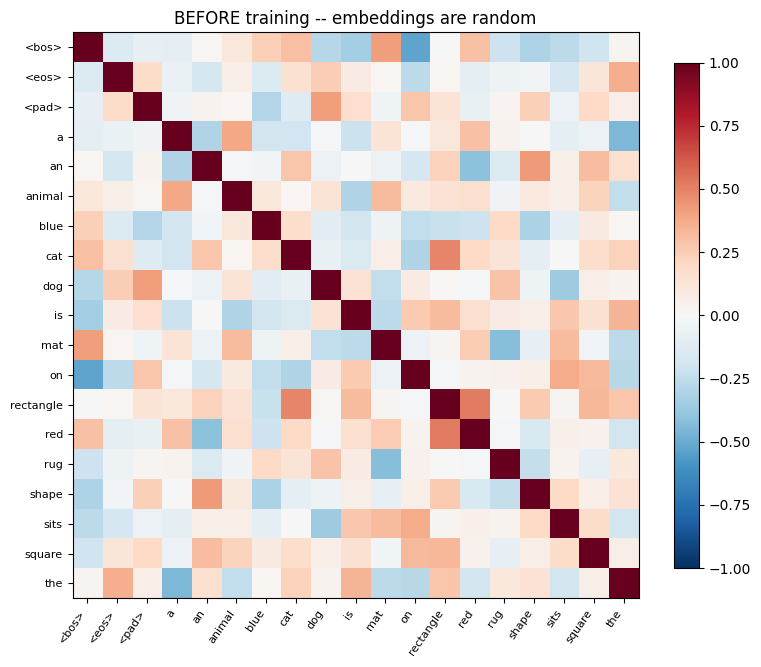

In [4]:
def plot_embedding_similarity(embedding_layer, title="Token embedding cosine similarity"):
    ids = torch.arange(len(vocab), device=device)
    vecs = embedding_layer(ids).detach().cpu()
    norms = vecs / vecs.norm(dim=1, keepdim=True)
    sim = norms @ norms.T

    labels = [itos[i] for i in range(len(vocab))]
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(sim.numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_embedding_similarity(embed, "BEFORE training -- embeddings are random")


---
## 3 · RMSNorm

MiniMax-M2 (and most modern LLMs) use **RMSNorm** instead of the
classic LayerNorm.  The idea is simple:

$$\text{RMSNorm}(\mathbf{x}) = \frac{\mathbf{x}}{\text{RMS}(\mathbf{x})} \odot \boldsymbol{\gamma}$$

where $\text{RMS}(\mathbf{x}) = \sqrt{\frac{1}{d}\sum_i x_i^2}$ and
$\boldsymbol{\gamma}$ is a learnable per-dimension scale.

**Why not LayerNorm?**  RMSNorm drops the mean-subtraction step, which
saves compute and works just as well in practice.

**Connection to the original:**
```python
class MiniMaxM2RMSNorm(nn.Module):
    def forward(self, hidden_states):
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)          # cast up
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states.to(input_dtype)       # cast back
```

Note that the production code **casts to float32** for the computation,
then casts back. This prevents numerical issues with half-precision
training. Our version does the same.


In [5]:
class RMSNorm(nn.Module):
    # Root-Mean-Square Layer Normalization (matches MiniMaxM2RMSNorm)
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        # Cast to float32 for numerical stability, like the original
        input_dtype = x.dtype
        x = x.float()
        rms = x.pow(2).mean(dim=-1, keepdim=True)
        x = x * torch.rsqrt(rms + self.eps)
        return (self.weight * x).to(input_dtype)

# -- Quick demo --
norm = RMSNorm(d_model)
sample = torch.randn(1, 5, d_model)
normed = norm(sample)

print("Input  std per token:", [f"{v:.3f}" for v in sample[0].std(dim=-1).tolist()])
print("Output std per token:", [f"{v:.3f}" for v in normed[0].std(dim=-1).detach().tolist()])
print()
print("Key insight: RMSNorm rescales each token vector to roughly unit RMS,")
print("then the learnable weight can stretch or shrink individual dimensions.")


Input  std per token: ['0.816', '0.981', '0.885', '0.935', '1.324']
Output std per token: ['0.920', '0.954', '0.958', '0.987', '0.984']

Key insight: RMSNorm rescales each token vector to roughly unit RMS,
then the learnable weight can stretch or shrink individual dimensions.


---
## 4 · Rotary Position Embeddings (RoPE)

Transformers process tokens in parallel, so they have no built-in notion
of word order. **RoPE** injects position information by *rotating*
query/key vectors using position-dependent angles.

### The math in brief

Each dimension pair $(x_{2i}, x_{2i+1})$ is rotated by angle
$\theta_i \cdot p$ where $p$ is the position and
$\theta_i = 10000^{-2i/d}$.

$$\begin{bmatrix} x'_{2i} \\ x'_{2i+1} \end{bmatrix}
= \begin{bmatrix} \cos(p\theta_i) & -\sin(p\theta_i) \\
                    \sin(p\theta_i) &  \cos(p\theta_i) \end{bmatrix}
  \begin{bmatrix} x_{2i} \\ x_{2i+1} \end{bmatrix}$$

**Why rotations?**  Because $\mathbf{q}_m^T \mathbf{k}_n$ after rotation
depends only on the *relative* distance $m - n$, which is exactly what
we want for language.

**Connection to the original:**
The production model has a dedicated `MiniMaxM2RotaryEmbedding` class
that pre-computes frequencies and supports dynamic rope scaling.  Our
version hard-codes base = 10000 and rebuilds each call (fine for tiny
sequences).


In [6]:
def rotate_half(x):
    # Swap and negate halves: the fast way to apply a 2D rotation
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat([-x2, x1], dim=-1)

def build_rope_cache(seq_len, head_dim, device):
    # Pre-compute cos/sin tables for every position
    assert head_dim % 2 == 0, "head_dim must be even for RoPE"
    inv_freq = 1.0 / (10000 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
    positions = torch.arange(seq_len, device=device).float()
    freqs = torch.outer(positions, inv_freq)   # (seq_len, head_dim/2)
    emb = torch.cat([freqs, freqs], dim=-1)    # duplicate for full head_dim
    cos = emb.cos()[None, None, :, :]           # (1, 1, T, head_dim)
    sin = emb.sin()[None, None, :, :]
    return cos, sin

def apply_rope(q, k):
    # Apply rotary embeddings to query and key tensors
    _, _, seq_len, head_dim = q.shape
    cos, sin = build_rope_cache(seq_len, head_dim, q.device)
    q = q * cos + rotate_half(q) * sin
    k = k * cos + rotate_half(k) * sin
    return q, k


### Visualizing RoPE frequencies

Below we plot the cos/sin values for each position and each dimension
pair.  Notice how the first pair oscillates very fast (high frequency)
while later pairs change slowly — this gives the model both fine-grained
local position info and coarse long-range position info.


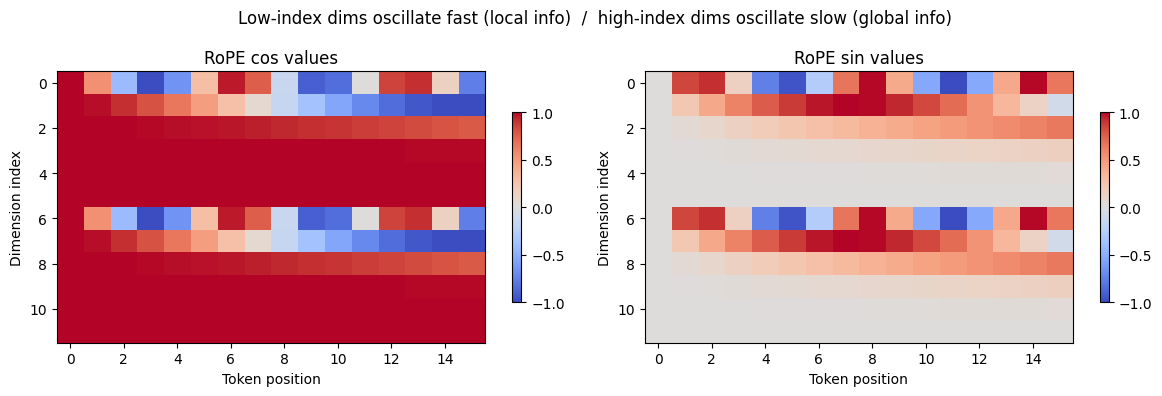

Key insight: when computing q*k, the rotation means the dot product
naturally depends on the RELATIVE position (m - n), not the absolute positions.


In [7]:
# Visualize RoPE for a 16-position, 12-dim-per-head setup
seq_demo, hdim_demo = 16, 12
cos_demo, sin_demo = build_rope_cache(seq_demo, hdim_demo, "cpu")
cos_np = cos_demo[0, 0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, name in zip(axes, [cos_np, sin_demo[0,0].numpy()], ["cos", "sin"]):
    im = ax.imshow(data.T, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xlabel("Token position")
    ax.set_ylabel("Dimension index")
    ax.set_title(f"RoPE {name} values")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle("Low-index dims oscillate fast (local info)  /  high-index dims oscillate slow (global info)")
plt.tight_layout()
plt.show()

print("Key insight: when computing q*k, the rotation means the dot product")
print("naturally depends on the RELATIVE position (m - n), not the absolute positions.")


---
## 5 · Causal multi-head self-attention

This is the heart of any Transformer.  For each token:
1. Project the hidden state into **Query**, **Key**, **Value** vectors
2. Apply **RoPE** to Q and K
3. Compute attention scores: $\text{score}(i,j) = \frac{q_i \cdot k_j}{\sqrt{d_k}}$
4. Apply a **causal mask** so token $i$ cannot see tokens $j > i$
5. Softmax → weighted sum of values

### Production features we skip
| Feature | Real model | This notebook |
|---|---|---|
| Grouped-Query Attention (GQA) | 24 Q heads, 8 KV heads | Equal heads |
| QK-RMSNorm | Normalizes Q and K before RoPE | Skipped |
| KV cache | Stores past keys/values for fast generation | Recompute each time |
| Flash Attention / SDPA | Memory-efficient fused kernels | Naive matmul |

The algorithmic flow is identical; the production code just adds
efficiency tricks.


In [8]:
class TinyCausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads

        # Separate projections for Q, K, V  (no bias, matching the original)
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.o_proj = nn.Linear(d_model, d_model, bias=False)   # output projection

    def forward(self, x):
        B, T, C = x.shape

        # Project and reshape to (B, n_heads, T, head_dim)
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Apply rotary position embeddings
        q, k = apply_rope(q, k)

        # Scaled dot-product attention
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Causal mask: upper triangle -> -inf  (prevents looking at future tokens)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(causal_mask, float("-inf"))

        weights = F.softmax(scores, dim=-1)

        # Weighted sum of values
        out = weights @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.o_proj(out), weights


---
## 6 · Gated MLP expert (SwiGLU)

Each MoE expert is a small feed-forward network with a **gating
mechanism** called SwiGLU:

$$\text{Expert}(\mathbf{x}) = W_2 \bigl[\text{SiLU}(W_1 \mathbf{x}) \odot W_3 \mathbf{x}\bigr]$$

- $W_1$ and $W_3$ both project from `d_model` → `d_ff`
- The element-wise product ($\odot$) acts as a learned gate
- $W_2$ projects back from `d_ff` → `d_model`
- SiLU (a.k.a. Swish) is $x \cdot \sigma(x)$

This is identical to `MiniMaxM2MLP` in the production code.


In [9]:
class ExpertMLP(nn.Module):
    # One expert: a gated feed-forward block (SwiGLU)
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff, bias=False)   # gate projection
        self.w2 = nn.Linear(d_ff, d_model, bias=False)    # down projection
        self.w3 = nn.Linear(d_model, d_ff, bias=False)    # up projection

    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

# Quick shape check
expert = ExpertMLP(d_model, 48)
dummy = torch.randn(2, d_model)
print(f"Expert input shape:  {tuple(dummy.shape)}")
print(f"Expert output shape: {tuple(expert(dummy).shape)}")
print(f"Expert parameters:   {sum(p.numel() for p in expert.parameters()):,}")


Expert input shape:  (2, 24)
Expert output shape: (2, 24)
Expert parameters:   3,456


---
## 7 · Sparse Mixture-of-Experts (MoE) routing

Instead of one large feed-forward block, MoE uses **many small experts**
and a **router** that decides which expert(s) process each token.

### How it works in the original

1. A linear *gate* projects each token to `num_experts` logits
2. Apply **sigmoid** (not softmax!) to get routing scores
3. Add a learned `e_score_correction_bias` (for load balancing)
4. **Top-k** selection picks the best 8 experts per token
5. Normalize the selected weights so they sum to 1
6. Each expert processes its assigned tokens, outputs are scaled by
   the routing weight and summed

### Our simplification

- **Top-1** instead of top-8 (easier to visualize)
- No `e_score_correction_bias`
- Same sigmoid routing and weight-scaling

> **Bug fix vs. the previous version of this notebook:** the previous
> version did *not* scale expert outputs by the router weight.  The
> original code does: `current_hidden_states = self[expert_idx](...) * top_k_weights[...]`.
> This is now corrected below.


In [10]:
class TinySparseMoE(nn.Module):
    # Sparse Mixture-of-Experts with top-1 routing (sigmoid gate)
    def __init__(self, d_model, d_ff, num_experts=3):
        super().__init__()
        self.num_experts = num_experts
        self.router = nn.Linear(d_model, num_experts, bias=False)
        self.experts = nn.ModuleList([ExpertMLP(d_model, d_ff) for _ in range(num_experts)])

    def forward(self, x):
        B, T, C = x.shape
        flat = x.reshape(B * T, C)

        # Step 1: compute routing scores (sigmoid, like the original)
        router_logits = self.router(flat)           # (B*T, num_experts)
        router_probs  = torch.sigmoid(router_logits)

        # Step 2: pick the top-1 expert per token
        top1_weight, chosen_expert = router_probs.max(dim=-1)  # both (B*T,)

        # Step 3: dispatch tokens to experts and scale by routing weight
        out = torch.zeros_like(flat)
        for expert_id, expert_fn in enumerate(self.experts):
            mask = (chosen_expert == expert_id)
            if not mask.any():
                continue
            token_positions = mask.nonzero(as_tuple=False).flatten()
            expert_in  = flat[token_positions]
            expert_out = expert_fn(expert_in)
            # IMPORTANT: Scale by routing weight (matches original code)
            expert_out = expert_out * top1_weight[token_positions, None]
            out.index_add_(0, token_positions, expert_out)

        out = out.view(B, T, C)
        chosen_expert = chosen_expert.view(B, T)
        router_probs  = router_probs.view(B, T, self.num_experts)
        return out, router_logits, router_probs, chosen_expert


---
## 8 · Load-balancing auxiliary loss

Without encouragement the router might send *all* tokens to one expert,
wasting the others. The **auxiliary loss** penalises imbalanced routing
by multiplying:

$$\mathcal{L}_{\text{aux}} = N \sum_{e=1}^{N} f_e \cdot p_e$$

where $f_e$ = fraction of tokens routed to expert $e$ and
$p_e$ = average routing probability for expert $e$.

This comes from the *Switch Transformer* paper (Fedus et al., 2021).
When routing is perfectly balanced, $f_e = 1/N$ for all experts and
the loss is minimised.

The production code's standalone `load_balancing_loss_func` uses softmax
on the logits (a legacy from Mixtral), whereas the actual routing uses
sigmoid.  Our version uses **sigmoid** consistently, matching the MoE
block's own routing.


In [11]:
def load_balancing_loss(router_logits, num_experts):
    # Auxiliary loss encouraging balanced expert utilisation
    probs  = torch.sigmoid(router_logits)               # (tokens, experts)
    chosen = probs.argmax(dim=-1)                        # (tokens,)
    # What fraction of tokens went to each expert?
    fraction_of_tokens = F.one_hot(chosen, num_classes=num_experts).float().mean(dim=0)
    # What is the average routing probability for each expert?
    average_router_prob = probs.mean(dim=0)
    # The product penalises experts that get both many tokens AND high prob
    return num_experts * torch.sum(fraction_of_tokens * average_router_prob)


---
## 9 · Decoder layer

Each decoder layer follows this pattern (identical to
`MiniMaxM2DecoderLayer`):

```
    +--- x -----------------------+
    |  RMSNorm -> Self-Attention  |
    +-------- + residual ---------+
    +--- x -----------------------+
    |  RMSNorm -> MoE FFN         |
    +-------- + residual ---------+
```

The **pre-norm** design (normalize *before* each sub-layer) is standard
in modern LLMs and was adopted from GPT-2 onward.


In [12]:
class TinyDecoderLayer(nn.Module):
    def __init__(self, d_model=24, n_heads=2, d_ff=48, num_experts=3):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn  = TinyCausalSelfAttention(d_model, n_heads)
        self.norm2 = RMSNorm(d_model)
        self.moe   = TinySparseMoE(d_model, d_ff, num_experts)

    def forward(self, x):
        # Sub-layer 1: attention with residual
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out
        # Sub-layer 2: MoE with residual
        moe_out, router_logits, router_probs, chosen_expert = self.moe(self.norm2(x))
        x = x + moe_out
        return x, attn_weights, router_logits, router_probs, chosen_expert


---
## 10 · Tiny causal language model

The full model stacks the pieces:

1. **Embedding** — token IDs → vectors
2. **Decoder layer(s)** — attention + MoE
3. **Final RMSNorm**
4. **LM head** — vectors → logits over vocabulary

The LM head **shares weights** with the embedding layer
(`lm_head.weight = embed.weight`), which is standard practice and
matches the original's `_tied_weights_keys = ["lm_head.weight"]`.


In [13]:
class TinyMoETransformer(nn.Module):
    def __init__(self, vocab_size, pad_id, d_model=24, n_heads=2, d_ff=48, num_experts=3):
        super().__init__()
        self.pad_id      = pad_id
        self.num_experts = num_experts

        self.embed   = nn.Embedding(vocab_size, d_model)
        self.layer   = TinyDecoderLayer(d_model, n_heads, d_ff, num_experts)
        self.norm    = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying (matches original)
        self.lm_head.weight = self.embed.weight

    def forward(self, idx, targets=None):
        x = self.embed(idx)                                           # (B, T, d_model)
        x, attn_weights, router_logits, router_probs, chosen_expert = self.layer(x)
        x = self.norm(x)
        logits = self.lm_head(x)                                      # (B, T, vocab_size)

        loss = None
        aux_loss = None
        if targets is not None:
            # Next-token prediction: logits[:, t] should predict targets[:, t+1]
            loss = F.cross_entropy(
                logits[:, :-1, :].reshape(-1, logits.size(-1)),
                targets[:, 1:].reshape(-1),
                ignore_index=self.pad_id,
            )
            aux_loss = load_balancing_loss(router_logits, self.num_experts)

        return {
            "logits":         logits,
            "loss":           loss,
            "aux_loss":       aux_loss,
            "attention":      attn_weights,
            "router_logits":  router_logits,
            "router_probs":   router_probs,
            "chosen_expert":  chosen_expert,
        }

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=5):
        # Greedy auto-regressive generation (no sampling, no KV cache)
        self.eval()
        for _ in range(max_new_tokens):
            out = self(idx)
            next_token = out["logits"][:, -1, :].argmax(dim=-1, keepdim=True)
            idx = torch.cat([idx, next_token], dim=1)
            if next_token.item() == eos_id:
                break
        return idx


---
## 11 · Instantiate and inspect the model


In [14]:
model = TinyMoETransformer(
    vocab_size  = len(vocab),
    pad_id      = pad_id,
    d_model     = 24,
    n_heads     = 2,
    d_ff        = 48,
    num_experts = 3,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")
print()

# Break down by component
for name, module in [
    ("Embedding",  model.embed),
    ("Attention",  model.layer.attn),
    ("MoE block",  model.layer.moe),
    ("Final norm", model.norm),
]:
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:15s}: {n:6,} params  ({100*n/num_params:.1f}%)")

print()
print("Note: LM head shares weights with embedding, so it adds 0 new params.")


Total parameters: 13,272

  Embedding      :    456 params  (3.4%)
  Attention      :  2,304 params  (17.4%)
  MoE block      : 10,440 params  (78.7%)
  Final norm     :     24 params  (0.2%)

Note: LM head shares weights with embedding, so it adds 0 new params.


In [15]:
with torch.no_grad():
    out = model(batch)

print("Shape check (before training):")
print(f"  Logits:         {tuple(out['logits'].shape)}   -> (batch, seq_len, vocab_size)")
print(f"  Attention:      {tuple(out['attention'].shape)} -> (batch, heads, seq_len, seq_len)")
print(f"  Router probs:   {tuple(out['router_probs'].shape)} -> (batch, seq_len, num_experts)")
print(f"  Chosen expert:  {tuple(out['chosen_expert'].shape)} -> (batch, seq_len)")


Shape check (before training):
  Logits:         (6, 8, 19)   -> (batch, seq_len, vocab_size)
  Attention:      (6, 2, 8, 8) -> (batch, heads, seq_len, seq_len)
  Router probs:   (6, 8, 3) -> (batch, seq_len, num_experts)
  Chosen expert:  (6, 8) -> (batch, seq_len)


---
## 12 · Training loop

We overfit on the tiny corpus for demonstration.
The total loss is:

$$\mathcal{L} = \mathcal{L}_{\text{next-token}} + 0.01 \cdot \mathcal{L}_{\text{aux}}$$

The 0.01 coefficient matches the original's `router_aux_loss_coef`.


In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-2)

steps = 80      # more steps than the original so we learn better embeddings
history = []

model.train()
for step in range(steps):
    out = model(batch, targets=batch)
    total_loss = out["loss"] + 0.01 * out["aux_loss"]

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    history.append((float(out["loss"]), float(out["aux_loss"])))

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:03d}  "
            f"next-token loss={out['loss'].item():.4f}  "
            f"aux loss={out['aux_loss'].item():.4f}"
        )


/tmp/ipykernel_33251/1737304518.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  history.append((float(out["loss"]), float(out["aux_loss"])))


step=000  next-token loss=23.4188  aux loss=1.4693
step=010  next-token loss=1.5955  aux loss=1.7782
step=020  next-token loss=1.1034  aux loss=1.5895
step=030  next-token loss=0.6527  aux loss=1.6087
step=040  next-token loss=0.6747  aux loss=1.6621
step=050  next-token loss=0.3518  aux loss=1.6845
step=060  next-token loss=0.2968  aux loss=1.6809
step=070  next-token loss=0.3243  aux loss=1.6402
step=079  next-token loss=0.2784  aux loss=1.6145


### Training loss curves

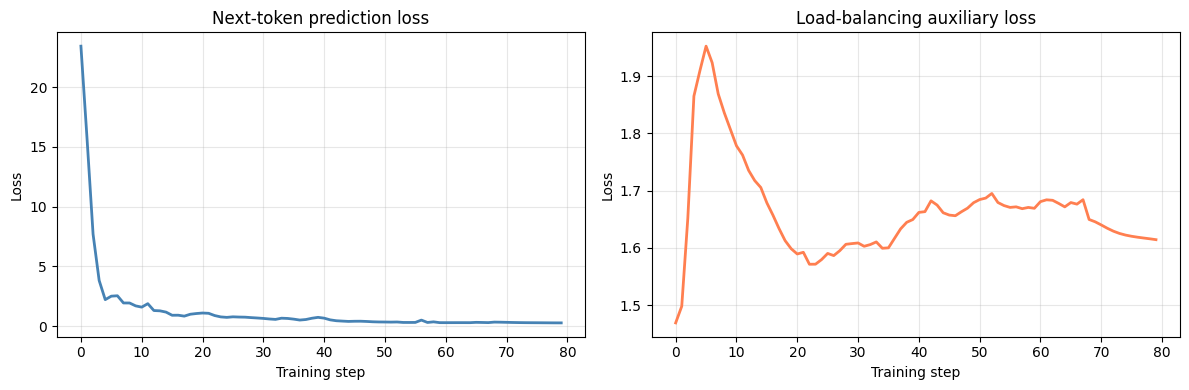

In [17]:
main_losses = [x[0] for x in history]
aux_losses  = [x[1] for x in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(main_losses, color="steelblue", linewidth=2)
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")
ax1.set_title("Next-token prediction loss")
ax1.grid(True, alpha=0.3)

ax2.plot(aux_losses, color="coral", linewidth=2)
ax2.set_xlabel("Training step")
ax2.set_ylabel("Loss")
ax2.set_title("Load-balancing auxiliary loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 13 · Embedding analysis AFTER training

Now that the model has learned from the corpus, let's see if semantically
related tokens have moved closer together in embedding space.


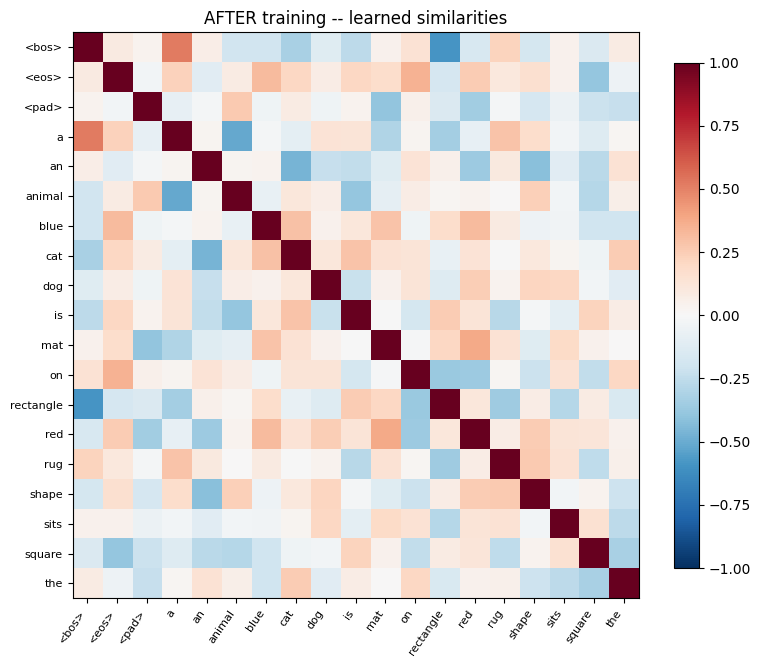

In [18]:
plot_embedding_similarity(model.embed, "AFTER training -- learned similarities")

### 2-D projection of token embeddings (PCA)

We project the 24-dimensional embeddings down to 2D using PCA so we
can visualize clusters.


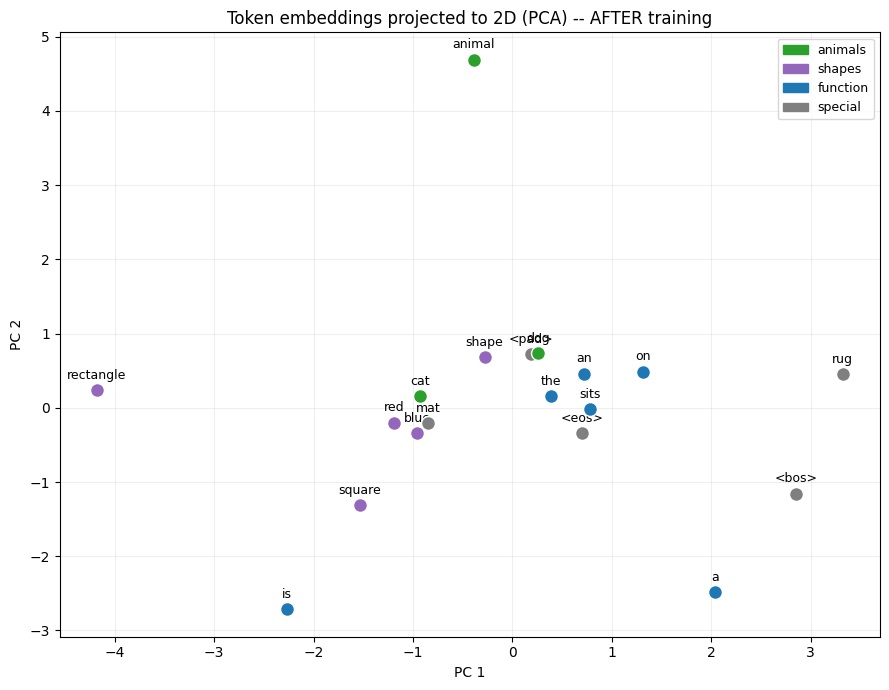

Look for clusters: 'cat' and 'dog' should be near each other,
'square' and 'rectangle' should be near each other, etc.


In [19]:
ids = torch.arange(len(vocab), device=device)
vecs = model.embed(ids).detach().cpu().numpy()

# Simple PCA via SVD
vecs_centered = vecs - vecs.mean(axis=0)
U, S, Vt = np.linalg.svd(vecs_centered, full_matrices=False)
coords = U[:, :2] * S[:2]   # project onto first 2 principal components

# Color-code by semantic category
categories = {
    "animals":  ["cat", "dog", "animal"],
    "shapes":   ["square", "rectangle", "shape", "red", "blue"],
    "function": ["the", "a", "an", "is", "on", "sits"],
    "special":  ["<bos>", "<eos>", "<pad>", "mat", "rug"],
}
palette = {"animals": "tab:green", "shapes": "tab:purple", "function": "tab:blue", "special": "tab:gray"}
category_colors = {}
for cat, words in categories.items():
    for w in words:
        if w in stoi:
            category_colors[w] = palette[cat]

fig, ax = plt.subplots(figsize=(9, 7))
for i, label in enumerate([itos[j] for j in range(len(vocab))]):
    color = category_colors.get(label, "tab:gray")
    ax.scatter(coords[i, 0], coords[i, 1], c=color, s=100, zorder=5, edgecolors="white")
    ax.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=9,
                ha="center", va="bottom", textcoords="offset points", xytext=(0, 6))

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=handles, loc="best", fontsize=9)
ax.set_title("Token embeddings projected to 2D (PCA) -- AFTER training")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Look for clusters: 'cat' and 'dog' should be near each other,")
print("'square' and 'rectangle' should be near each other, etc.")


---
## 14 · Inspecting attention patterns

Below we visualize the attention weights for both heads on the first
sentence.  Because of the causal mask, all weight above the diagonal is
zero — a token can only attend to itself and earlier tokens.


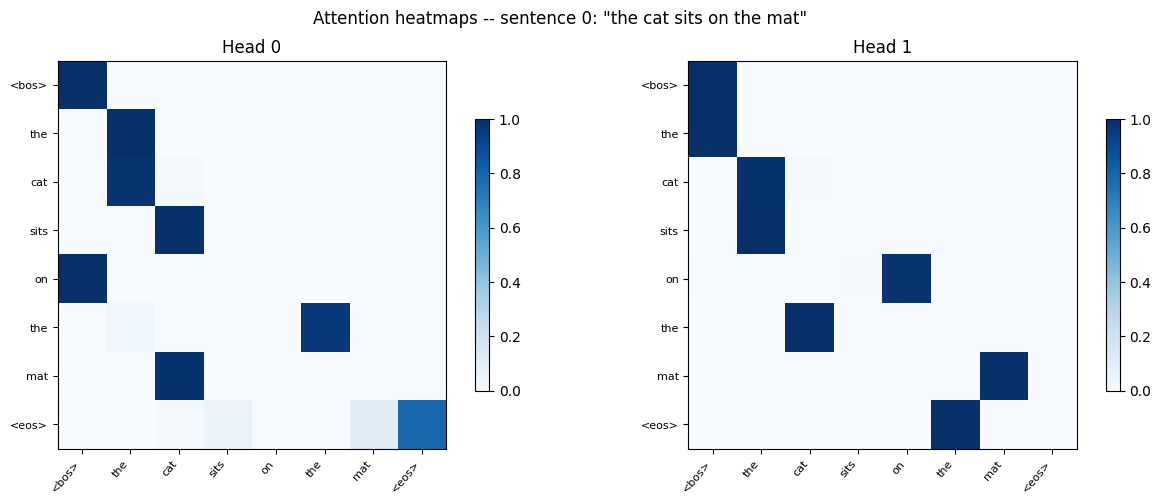

Reading the heatmap: row = query token, column = key token.
High values mean the query token is 'paying attention' to that key token.


In [20]:
model.eval()
with torch.no_grad():
    out = model(batch)

tokens0 = [itos[int(i)] for i in batch[0].tolist() if int(i) != pad_id]
T0 = len(tokens0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for head_idx, ax in enumerate(axes):
    attn = out["attention"][0, head_idx, :T0, :T0].detach().cpu()
    im = ax.imshow(attn, cmap="Blues")
    ax.set_xticks(range(T0))
    ax.set_yticks(range(T0))
    ax.set_xticklabels(tokens0, rotation=50, ha="right", fontsize=8)
    ax.set_yticklabels(tokens0, fontsize=8)
    ax.set_title(f"Head {head_idx}")
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle('Attention heatmaps -- sentence 0: "the cat sits on the mat"', fontsize=12)
plt.tight_layout()
plt.show()

print("Reading the heatmap: row = query token, column = key token.")
print("High values mean the query token is 'paying attention' to that key token.")


---
## 15 · MoE routing inspection

For each token, which expert did the router pick?
And how confident was it (what were the routing probabilities)?


In [21]:
chosen = out["chosen_expert"].detach().cpu()
rprobs = out["router_probs"].detach().cpu()

print("Token -> Expert assignment (with routing probabilities):\n")
for row in range(batch.size(0)):
    token_ids = batch[row].detach().cpu().tolist()
    tokens = [itos[i] for i in token_ids if i != pad_id]
    experts = chosen[row][:len(tokens)].tolist()
    probs   = rprobs[row][:len(tokens)]

    parts = []
    for tok, exp, p in zip(tokens, experts, probs):
        prob_str = f"{p[exp]:.2f}"
        parts.append(f"{tok}->E{exp}({prob_str})")
    print(f"  Sentence {row}: {' | '.join(parts)}")


Token -> Expert assignment (with routing probabilities):

  Sentence 0: <bos>->E2(0.95) | the->E0(0.63) | cat->E0(0.94) | sits->E0(0.93) | on->E2(0.95) | the->E0(0.54) | mat->E1(0.94) | <eos>->E0(0.91)
  Sentence 1: <bos>->E2(0.95) | the->E0(0.63) | dog->E0(0.98) | sits->E0(0.97) | on->E2(0.95) | the->E0(0.76) | rug->E0(0.78) | <eos>->E0(0.92)
  Sentence 2: <bos>->E2(0.95) | a->E2(0.91) | cat->E1(0.91) | is->E1(0.85) | an->E2(0.76) | animal->E0(0.91) | <eos>->E1(0.66)
  Sentence 3: <bos>->E2(0.95) | a->E2(0.91) | dog->E0(0.84) | is->E1(0.80) | an->E2(0.76) | animal->E0(0.91) | <eos>->E1(0.66)
  Sentence 4: <bos>->E2(0.95) | a->E2(0.91) | red->E2(0.77) | square->E2(0.86) | is->E1(0.99) | a->E2(0.81) | shape->E0(0.69) | <eos>->E1(0.97)
  Sentence 5: <bos>->E2(0.95) | a->E2(0.91) | blue->E2(0.77) | rectangle->E2(0.90) | is->E1(0.99) | a->E2(0.81) | shape->E0(0.69) | <eos>->E1(0.59)


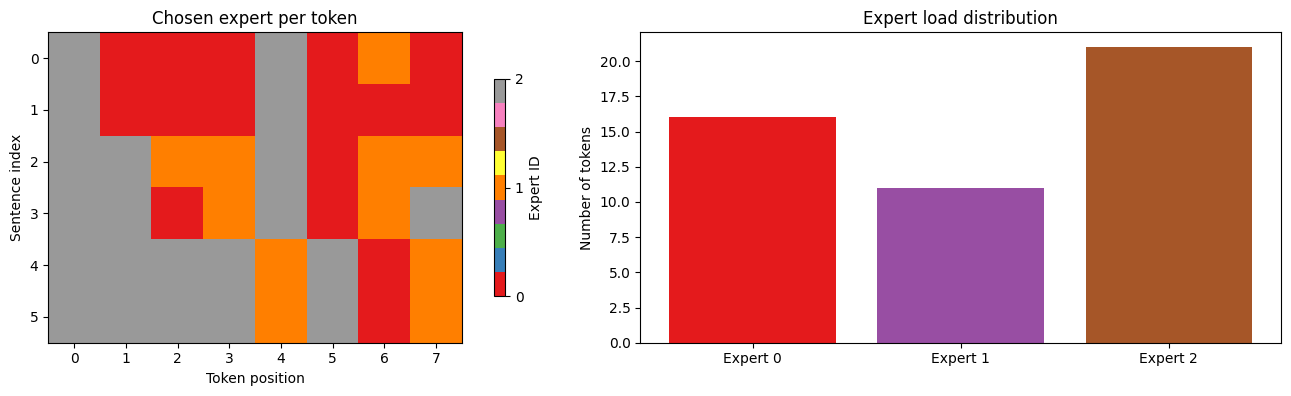

If the aux loss is working, tokens should be spread across experts,
not all funneled to a single one.


In [22]:
# Routing heatmap: which expert handles which token?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: chosen expert
routing_matrix = out["chosen_expert"].detach().cpu().float()
im1 = axes[0].imshow(routing_matrix, cmap="Set1", vmin=0, vmax=2)
axes[0].set_xlabel("Token position")
axes[0].set_ylabel("Sentence index")
axes[0].set_title("Chosen expert per token")
fig.colorbar(im1, ax=axes[0], shrink=0.7, ticks=[0, 1, 2], label="Expert ID")

# Right: expert load histogram
expert_counts = [0, 0, 0]
all_chosen = out["chosen_expert"].detach().cpu().flatten()
for e in range(3):
    expert_counts[e] = (all_chosen == e).sum().item()

colors = plt.cm.Set1(np.array([0, 1, 2]) / 3)
axes[1].bar(range(3), expert_counts, color=colors[:3])
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(["Expert 0", "Expert 1", "Expert 2"])
axes[1].set_ylabel("Number of tokens")
axes[1].set_title("Expert load distribution")

plt.tight_layout()
plt.show()

print("If the aux loss is working, tokens should be spread across experts,")
print("not all funneled to a single one.")


### Router probability distribution per expert

This shows the full sigmoid probability each expert received, not just
which one "won".  You can see how the router learns to differentiate.


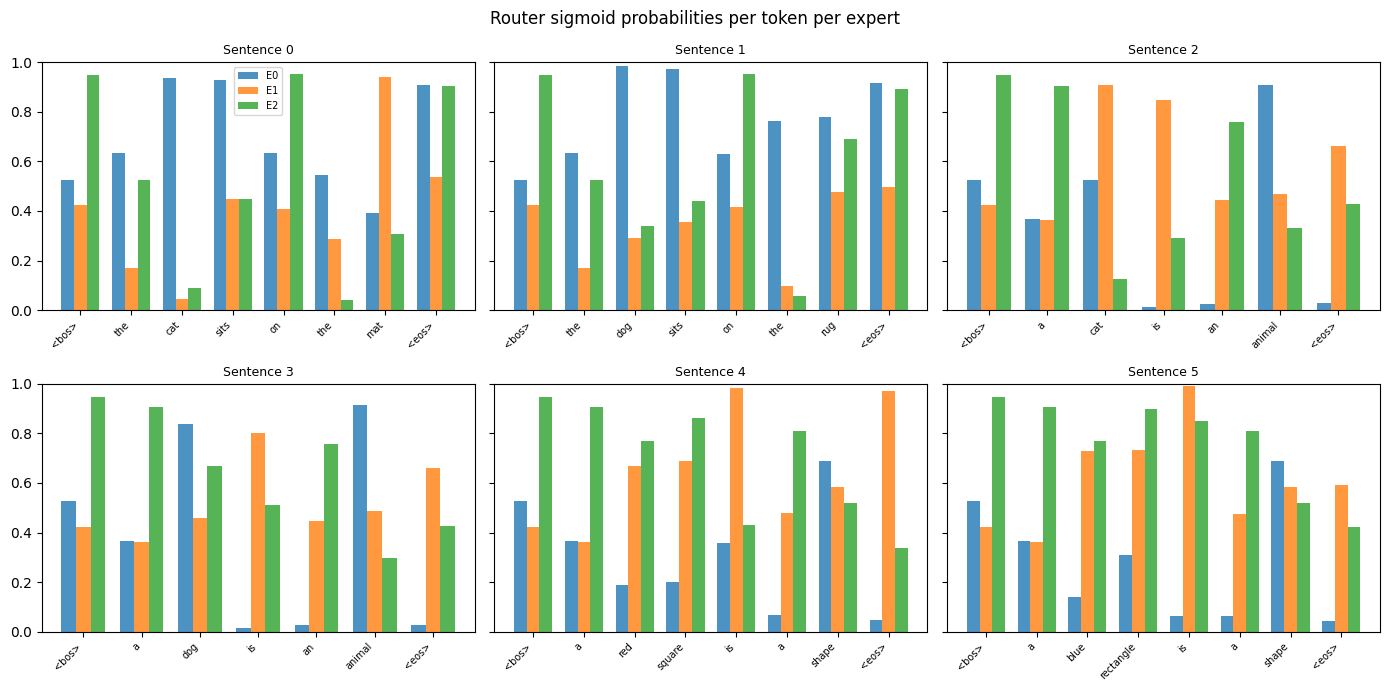

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for row in range(min(batch.size(0), 6)):
    ax = axes[row // 3, row % 3]
    token_ids = batch[row].detach().cpu().tolist()
    tokens = [itos[i] for i in token_ids if i != pad_id]
    n_tok = len(tokens)
    probs = rprobs[row, :n_tok].numpy()

    x = np.arange(n_tok)
    width = 0.25
    for e in range(3):
        ax.bar(x + e * width, probs[:, e], width, label=f"E{e}", alpha=0.8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"Sentence {row}", fontsize=9)
    if row == 0:
        ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

plt.suptitle("Router sigmoid probabilities per token per expert", fontsize=12)
plt.tight_layout()
plt.show()


---
## 16 · Text generation

We feed a prompt and greedily extend it one token at a time.
This is a minimal version of the real model's `generate()` method.


In [24]:
prompts = [
    ["<bos>", "the", "cat"],
    ["<bos>", "a", "dog"],
    ["<bos>", "a", "red"],
]

model.eval()
for prompt_tokens in prompts:
    prompt_ids = torch.tensor([[stoi[t] for t in prompt_tokens]], device=device)
    generated = model.generate(prompt_ids, max_new_tokens=6)[0].detach().cpu().tolist()
    print(f"  Prompt:    {' '.join(prompt_tokens)}")
    print(f"  Generated: {decode(generated)}")
    print()


  Prompt:    <bos> the cat
  Generated: <bos> the cat sits on the mat <eos>

  Prompt:    <bos> a dog
  Generated: <bos> a dog is an animal <eos>

  Prompt:    <bos> a red
  Generated: <bos> a red square is a shape <eos>



---
## 17 · Component deep-dive: understanding each piece

### Why weight tying?
The embedding and LM head both map between token IDs and vectors.
Tying them forces the model to use a single, shared representation of
each token, which acts as a regularizer and cuts parameters nearly in half
for the embedding + head.

### Why sigmoid routing instead of softmax?
The original MiniMax model uses **sigmoid** per-expert scores rather than
softmax across experts.  This means experts are scored *independently*:
two experts can both get high scores (or both low).  Combined with top-k
selection and re-normalization, this gives more flexible routing than
softmax, which forces a zero-sum competition.

### Why `e_score_correction_bias`?
The production model has a per-expert learnable bias added to routing
scores *before* top-k selection.  This nudges the router toward
underused experts — a second line of defense for load balancing beyond
the auxiliary loss.

### Why QK-norm?
MiniMax-M2 applies RMSNorm to Q and K *before* RoPE.  This prevents
the attention logits from growing too large as training proceeds, which
stabilises training at scale.  Our toy model doesn't need it (24-dim
vectors don't blow up), but it's a critical feature at 3072-dim.

### Why Grouped-Query Attention (GQA)?
The real model uses 24 query heads but only 8 key/value heads.  Each KV
head is *shared* among 3 query heads.  This cuts KV-cache memory by 3x
during inference with minimal quality loss.


---
## 18 · Student exercises

1. **Change `num_experts`** from 3 to 2 or 4.  How does routing change?
2. **Increase training steps** to 200+.  Does the next-token loss reach 0?
3. **Implement top-2 routing:**  modify `TinySparseMoE` to pick 2 experts
   per token, normalize their weights, and sum the outputs.
4. **Add a second decoder layer:**  change `TinyMoETransformer` to stack
   two `TinyDecoderLayer` modules.
5. **Add QK-norm:**  apply `RMSNorm` to Q and K inside the attention
   module before the RoPE step.
6. **Dense vs. MoE comparison:**  replace the MoE block with a single
   `ExpertMLP` and compare convergence speed.
7. **Expert specialization:**  after training, print which token
   *types* each expert handles most often.  Do you see patterns?
8. **Temperature sampling:**  modify `generate()` to sample from a
   softmax with temperature instead of argmax.  How does the output change?
